# Identify Patterns in Weather Data

This notebook analyzes weather sensor data from two solar plants and investigates its relationship with power generation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
plt.style.use('ggplot')
sns.set_palette('viridis')

## Loading Data

In [2]:
# Weather Data Paths
w1_path = '../../data/Plant_1_Weather_Sensor_Data (2).csv'
w2_path = '../../data/Plant_2_Weather_Sensor_Data (1).csv'

# Generation Data Paths (for correlation analysis)
p1_path = '../../data/Plant_1_Generation_Data (2).csv'
p2_path = '../../data/Plant_2_Generation_Data (2).csv'

w1 = pd.read_csv(w1_path)
w2 = pd.read_csv(w2_path)
p1 = pd.read_csv(p1_path)
p2 = pd.read_csv(p2_path)

# Preprocess Datetimes
w1['DATE_TIME'] = pd.to_datetime(w1['DATE_TIME'])
w2['DATE_TIME'] = pd.to_datetime(w2['DATE_TIME'])
p1['DATE_TIME'] = pd.to_datetime(p1['DATE_TIME'], dayfirst=True)
p2['DATE_TIME'] = pd.to_datetime(p2['DATE_TIME'])

w1['PLANT'] = 'Plant_1'
w2['PLANT'] = 'Plant_2'
p1['PLANT'] = 'Plant_1'
p2['PLANT'] = 'Plant_2'

weather = pd.concat([w1, w2])
generation = pd.concat([p1, p2])

weather.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,PLANT
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,Plant_1
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0,Plant_1
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0,Plant_1
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0,Plant_1
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0,Plant_1


### 1. Split Weather Data by Source Key

In [3]:
# Weather sensors also have unique SOURCE_KEYs
weather_sources = weather.groupby('SOURCE_KEY')

print(f"Unique weather sensors: {weather.SOURCE_KEY.unique()}")

# Example: Accessing sensor data for Plant 1
p1_sensor = weather_sources.get_group(w1['SOURCE_KEY'].iloc[0])
p1_sensor.head()

Unique weather sensors: <StringArray>
['HmiyD2TTLFNqkNe', 'iq8k7ZNt4Mwm3w0']
Length: 2, dtype: str


,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,PLANT
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,Plant_1
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0,Plant_1
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0,Plant_1
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0,Plant_1
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0,Plant_1


### 2. What is "good weather" for the panels?

Good weather for solar panels usually means high **Irradiation** but moderate **Ambient Temperature**. High temperatures can actually decrease panel efficiency.

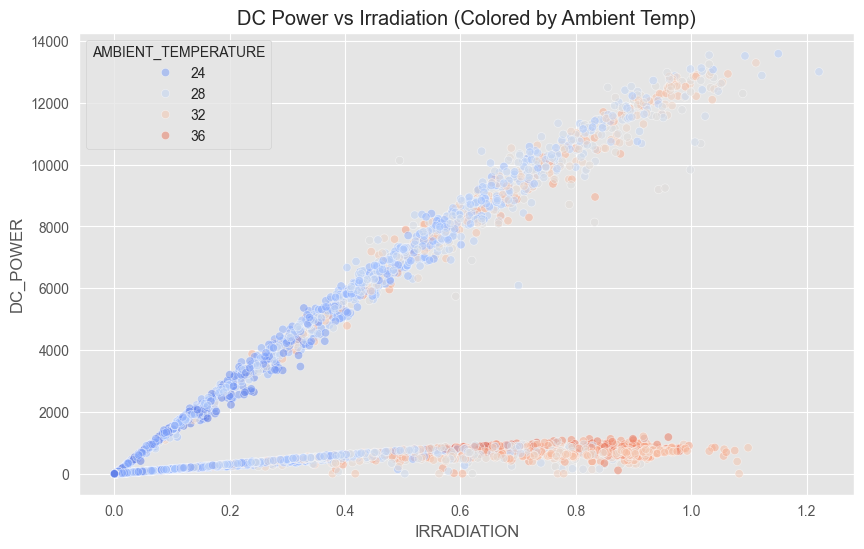

Ideal conditions: High irradiation and low-to-moderate ambient temperature.


In [4]:
# Merging generation and weather data to see the effect
# Note: We aggregate generation data by time and plant to match sensor data
gen_agg = generation.groupby(['DATE_TIME', 'PLANT'])[['DC_POWER', 'AC_POWER']].mean().reset_index()
merged_df = pd.merge(gen_agg, weather, on=['DATE_TIME', 'PLANT'])

plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged_df, x='IRRADIATION', y='DC_POWER', hue='AMBIENT_TEMPERATURE', palette='coolwarm', alpha=0.5)
plt.title('DC Power vs Irradiation (Colored by Ambient Temp)')
plt.show()

print("Ideal conditions: High irradiation and low-to-moderate ambient temperature.")

### 3. Are there any patterns?

We can look at the daily cycle of temperatures and irradiation.

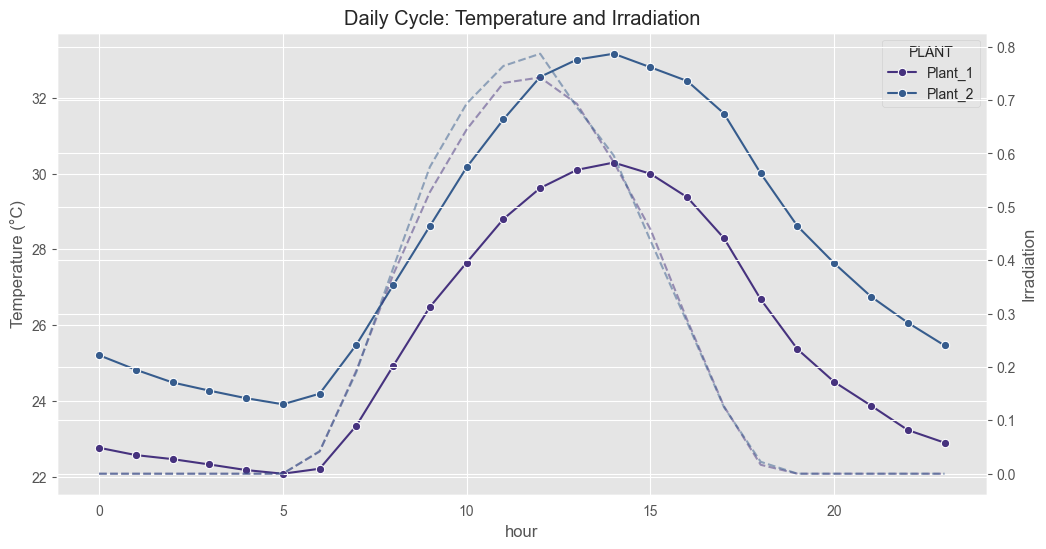

Pattern: Module temperature peaks with irradiation, while ambient temperature peaks slightly later (thermal lag).


In [5]:
weather['hour'] = weather['DATE_TIME'].dt.hour
hourly_weather = weather.groupby(['PLANT', 'hour'])[['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.lineplot(data=hourly_weather, x='hour', y='AMBIENT_TEMPERATURE', hue='PLANT', ax=ax1, marker='o')
ax1.set_ylabel('Temperature (°C)')

ax2 = ax1.twinx()
sns.lineplot(data=hourly_weather, x='hour', y='IRRADIATION', hue='PLANT', ax=ax2, linestyle='--', alpha=0.5)
ax2.set_ylabel('Irradiation')
ax2.get_legend().remove()

plt.title('Daily Cycle: Temperature and Irradiation')
plt.show()

print("Pattern: Module temperature peaks with irradiation, while ambient temperature peaks slightly later (thermal lag).")

### 4. Do they correlate with the hourly and/or daily fluctuations?

We'll examine if weather variability matches power variability.

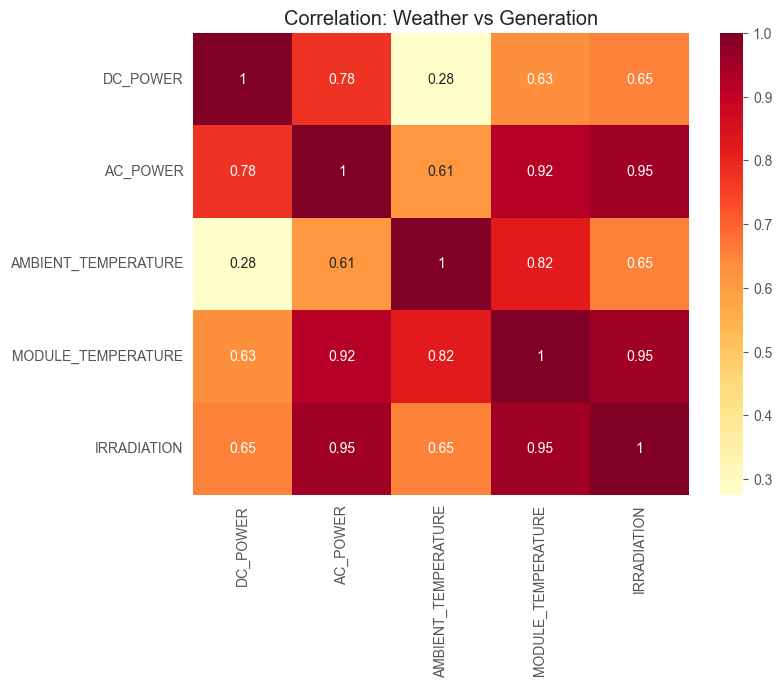

In [6]:
merged_df['hour'] = merged_df['DATE_TIME'].dt.hour

# Correlation between weather variables and power
weather_gen_corr = merged_df[['DC_POWER', 'AC_POWER', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(weather_gen_corr, annot=True, cmap='YlOrRd')
plt.title('Correlation: Weather vs Generation')
plt.show()

### 5. Additional Question: How does the Temperature Delta (Module - Ambient) relate to Irradiation?

This can indicate how efficiently panels are shedding heat or how much they are absorbing.

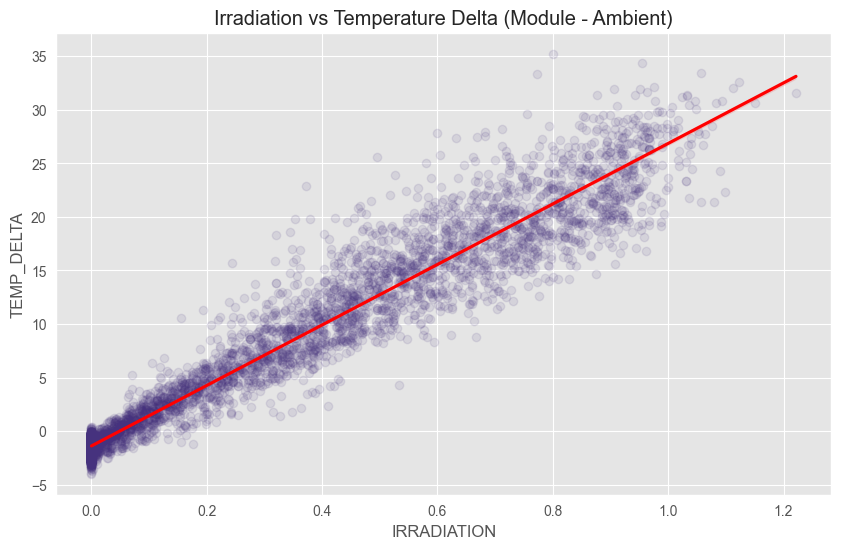

Observation: The gap between module and ambient temperature increases linearly with irradiation.


In [7]:
merged_df['TEMP_DELTA'] = merged_df['MODULE_TEMPERATURE'] - merged_df['AMBIENT_TEMPERATURE']

plt.figure(figsize=(10, 6))
sns.regplot(data=merged_df, x='IRRADIATION', y='TEMP_DELTA', scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.title('Irradiation vs Temperature Delta (Module - Ambient)')
plt.show()

print("Observation: The gap between module and ambient temperature increases linearly with irradiation.")

### 6. Additional Question: Is Plant 2 weather significantly different from Plant 1?

Since they are likely in different locations, we can compare their distributions.

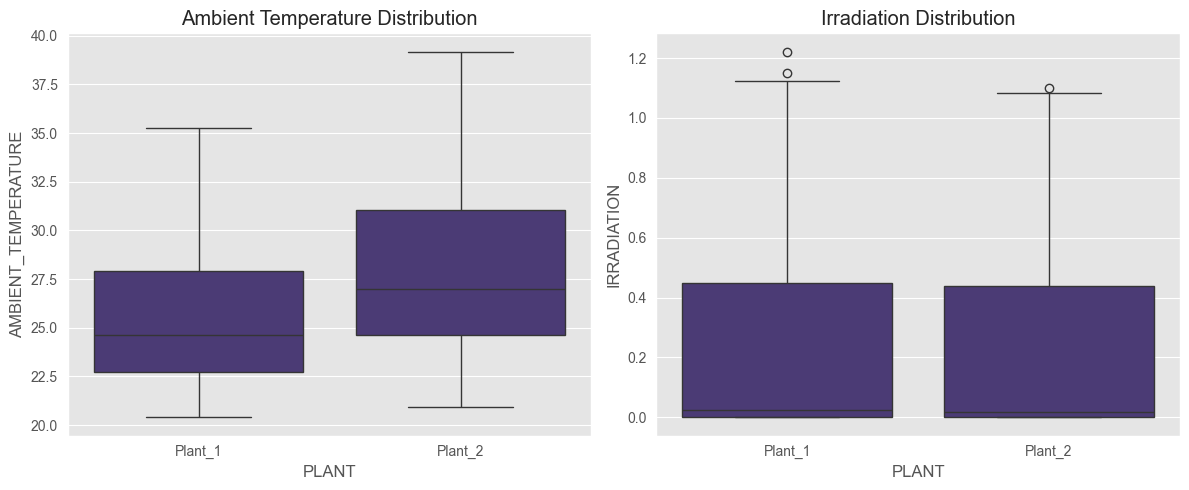

In [8]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=weather, x='PLANT', y='AMBIENT_TEMPERATURE')
plt.title('Ambient Temperature Distribution')

plt.subplot(1, 2, 2)
sns.boxplot(data=weather, x='PLANT', y='IRRADIATION')
plt.title('Irradiation Distribution')

plt.tight_layout()
plt.show()